# Figure 2: Plasmid selectivity

Tested in 293Ts, 20k cells/well at 96-well scale \ 
Sparsely labeled eGFP cells \ 
Transfected with minipreps



Reps:
- 2026.06.29: 20k/well (1 reps)
- 2026.07.02: 20k/well (2 reps)


**Load in Functions**

In [1]:
import rushd as rd
import matplotlib
import pandas as pd
import numpy as np
import scipy.stats as stats
import seaborn as sns
import matplotlib.pyplot as plt
from textwrap import wrap
from statannotations.Annotator import Annotator
from pathlib import Path
from scipy.optimize import curve_fit
from scipy.stats import poisson
from matplotlib.ticker import NullLocator

## Load Data from location

In [ ]:
# Set paths to the experiment folder and where to find the data
base_path = rd.datadir/'data'/'attune'/'Mary'

Plates = {'2026.06.29_exp57': ['Plate1'],
          '2026.07.02_exp60': ['Plate1', 'Plate2']
}

exp_path = []
yaml_path = []

for i in Plates:
    for j in Plates[i]:
        exp_path.append(base_path/i/j/'export_singlets')
        yaml_path.append(base_path/i/j/'export_singlets'/'well_metadata.yaml')

output_path = rd.rootdir/'output'/'Figure_2_selectivity'
cache_path = rd.rootdir/'output'/'Figure_2_selectivity'/'data_plasmid.gzip'

plates_dict = pd.DataFrame({
    'data_path' : [exp for exp in exp_path],
    'yaml_path' : [yaml for yaml in yaml_path]
})

display(plates_dict)

,data_path,yaml_path
0,C:\Users\chemegrad202\Nextcloud\data\attune\Ma...,C:\Users\chemegrad202\Nextcloud\data\attune\Ma...
1,C:\Users\chemegrad202\Nextcloud\data\attune\Ma...,C:\Users\chemegrad202\Nextcloud\data\attune\Ma...
2,C:\Users\chemegrad202\Nextcloud\data\attune\Ma...,C:\Users\chemegrad202\Nextcloud\data\attune\Ma...


**Load in Dataframe**

In [ ]:
#Load data
data = pd.DataFrame()

channel_list = ['mRuby2-A', 'mRuby2-H','mGL-H','mGL-A', 'iRFP670-A','iRFP670-H', 'FSC-A', 'SSC-A']
data = rd.flow.load_groups_with_metadata(plates_dict,columns=channel_list) #Could add in columns=channel_list here to get specific columns

# Remove negative values from dataframe
for c in channel_list: data = data[data[c] > 0]

# Remove NaN values
data.dropna(inplace=True)

# Save data in the cache path for easier loading next time
data.to_parquet(rd.outfile(cache_path))


In [ ]:
data['conds'] = data['reporter'] +'.'+ data['Plasmid'] 
display(data)

,reporter,Plasmid,Date,well,population,FSC-A,SSC-A,mGL-A,mGL-H,iRFP670-A,iRFP670-H,mRuby2-A,mRuby2-H,conds
1,Controls,0x,2026.06.29.x,A10,Single Cells,246866,174947,106,73,9073,8038,2514,2151,Controls.0x
3,Controls,0x,2026.06.29.x,A10,Single Cells,442587,223802,179,76,203,180,72,110,Controls.0x
4,Controls,0x,2026.06.29.x,A10,Single Cells,334906,233749,192,221,27090,22276,33194,31478,Controls.0x
5,Controls,0x,2026.06.29.x,A10,Single Cells,312244,486075,234,278,56947,46422,38434,34859,Controls.0x
6,Controls,0x,2026.06.29.x,A10,Single Cells,260696,224429,90,81,30565,27090,949,868,Controls.0x
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14984266,pKG05003,0.1x,2026.07.02.xx,H9,Single Cells,436866,377209,185,79,275,284,49,57,pKG05003.0.1x
14984267,pKG05003,0.1x,2026.07.02.xx,H9,Single Cells,205664,211029,230,106,30,69,25,71,pKG05003.0.1x
14984268,pKG05003,0.1x,2026.07.02.xx,H9,Single Cells,281344,140470,23,63,36,56,67,69,pKG05003.0.1x
14984269,pKG05003,0.1x,2026.07.02.xx,H9,Single Cells,332224,176772,21958,16275,154,161,273,135,pKG05003.0.1x


In [ ]:
# Grab the untransfected data
untransfected = data[(data['reporter'] == 'Untransfected')]

c:\Users\chemegrad202\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\chemegrad202\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
c:\Users\chemegrad202\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_ke

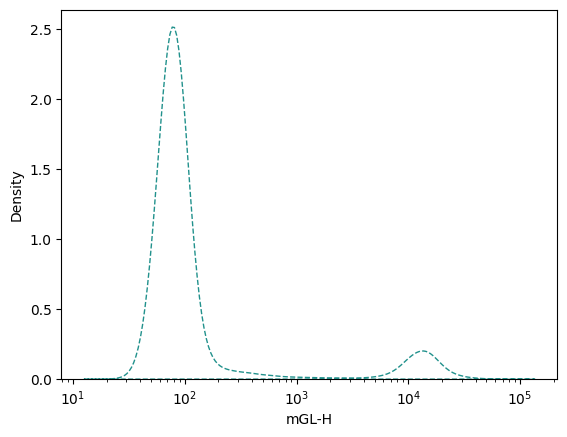

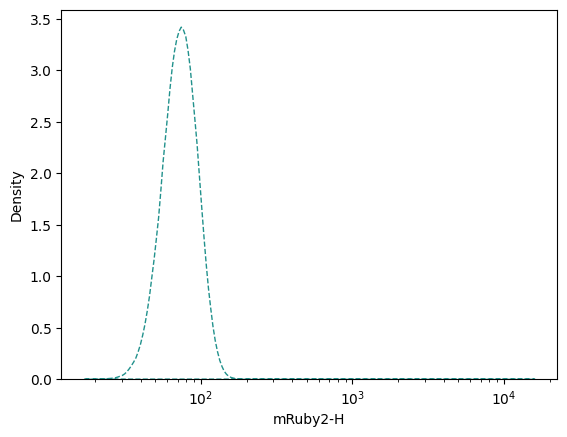

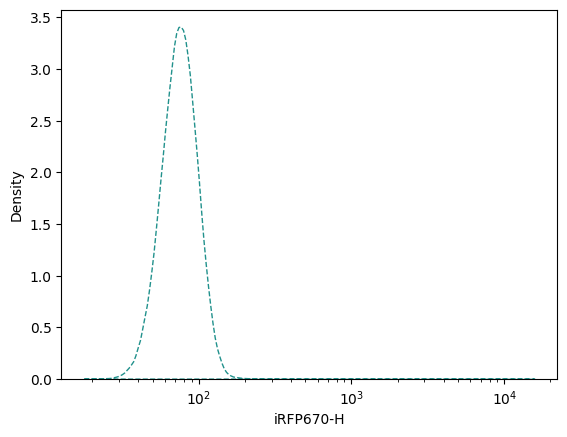

In [ ]:
parameters = np.array(['mGL-H', 'mRuby2-H', 'iRFP670-H'])
for param in parameters:
    g = plt.figure()
    sns.kdeplot(untransfected, x=param,hue='reporter',log_scale=True,legend=False,fill=True,common_norm=False,palette='viridis', alpha = 0, linestyle = '--')

**Set gates for FPs**

In [ ]:
# Set gates for data analysis

# Or use the percentile gating
iRFP_gate_quantile = untransfected['iRFP670-H'].quantile(0.99)
eGFP_gate = 3000
mRuby_gate = 500

# # Gating on co-transfection marker
data_gated = data[data['iRFP670-H'] > iRFP_gate_quantile]
data_eGFP = data[data['mGL-H'] > eGFP_gate]

## Gating for FP+ cells

In [11]:
mRuby2_gated = data[data['mRuby2-H'] > mRuby_gate].copy()
Double_gated = mRuby2_gated[mRuby2_gated['iRFP670-H'] > iRFP_gate_quantile].copy() 

In [12]:
mRuby2_gated['eGFP_cat'] = np.where(mRuby2_gated['mGL-H'] > eGFP_gate, 'eGFP+', 'eGFP-') 

In [20]:
well_group = ['conds']
count_df = mRuby2_gated.groupby(['conds','reporter', 'Date','eGFP_cat'])[
    'FSC-A'].count().unstack(fill_value=0).stack().rename('count')
percent_small_data_1_mRuby2 = (count_df*100/count_df.groupby(well_group ).transform('sum')).reset_index(name='percent')
count_small_data_1_mRuby2 = count_df.reset_index()
display(percent_small_data_1_mRuby2)

,conds,reporter,Date,eGFP_cat,percent
0,Controls.0x,Controls,2026.06.29.x,eGFP+,8.238705
1,Controls.0x,Controls,2026.06.29.x,eGFP-,91.761295
2,Untransfected.0x,Untransfected,2026.06.29.x,eGFP+,0.000000
3,Untransfected.0x,Untransfected,2026.06.29.x,eGFP-,100.000000
4,pKG04405.0.5x,pKG04405,2026.06.29.x,eGFP+,0.000000
...,...,...,...,...,...
93,pKG05003.1x,pKG05003,2026.06.29.x,eGFP-,21.126704
94,pKG05003.1x,pKG05003,2026.07.02.x,eGFP+,3.736012
95,pKG05003.1x,pKG05003,2026.07.02.x,eGFP-,35.415004
96,pKG05003.1x,pKG05003,2026.07.02.xx,eGFP+,3.668292


## Bar plots

c:\Users\chemegrad202\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\chemegrad202\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\chemegrad202\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)


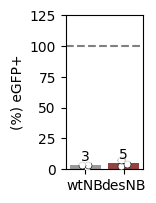

In [22]:
# General plotting params
x = 'conds'
y = 'percent'

# Conditions
order = ['pKG05003.1x', 'pKG05002.1x']
eGFP_cat = 'eGFP+'

df = percent_small_data_1_mRuby2.loc[(percent_small_data_1_mRuby2['eGFP_cat'] == eGFP_cat)]

palette = {
    'pKG05002.1x': 'darkred', 
    'pKG05003.1x': 'grey'
}
fig, ax = plt.subplots(1, 1, figsize=(1,2))

# Plot hyperP percent of all cells
sns.barplot(
    ax=ax, data=df,
    x=x, y=y,
    order=order,
    palette=palette,
    alpha=0.8)

sns.stripplot(
    ax=ax, data=df,
    x=x, y=y,
    order=order,
    dodge=True,
    color='white', size=5,
    edgecolor='black', linewidth=0.4,)



lmap = {
    'pKG05003.1x': 'wtNB', 
    'pKG05002.1x': 'desNB'
}
ax.set_xticklabels([lmap[cond] for cond in order])
ax.set_ylim((0, 125))
plt.axhline(y=100, color='grey', linestyle= '--')
ax.yaxis.set_label_text('(%) eGFP+')
# ax.set_title('mRuby2+ | 4 dpi (Lenti) | new plasmids')
ax.set_xlabel('')

# Add barplot labels
for sub_ax in plt.gcf().get_axes():
    for i in sub_ax.containers:
        bar_labels = sub_ax.bar_label(i, fmt='%0.0f', padding=1)
        for label in bar_labels:
            label.set_bbox(dict(facecolor='white', alpha=0.75, linewidth=0, pad=1))    

plottitle = 'Lenti_selectivity.svg'
plt.savefig(rd.outfile(output_path/plottitle),bbox_inches='tight')

## Contours

In [ ]:
# General plotting params
x = "mGL-H"
y = "mRuby2-H"
hue = "reporter"


hue_order = ['pKG05002', 'pKG05003','Untransfected']

# Conditions

palette = {
    'pKG05002': 'darkred', 
    'pKG05003': 'coral',
    'pKG04437': 'dodgerblue', 
    'pKG04440': 'midnightblue',
    'Untransfected': 'grey'
}

# Conditions

# only look at no selection and iRFP+ infected
small_data = pd.concat([data_gated, untransfected])
small_data= small_data.groupby('reporter').sample(n=2000, random_state=7, replace=True)


# definitions for the axes
left, width = 0.1, 0.65
bottom, height = 0.1, 0.65
spacing = 0.005

rect_scatter = [left, bottom, width, height]
rect_histx = [left, bottom + height + spacing, width, 0.2]
rect_histy = [left + width + spacing, bottom, 0.2, height]

# Set up figure
fig = plt.figure(figsize=(3,3))
ax_scatter = plt.axes(rect_scatter)
ax_scatter.tick_params(direction="in", top=True, right=True)
ax_histx = plt.axes(rect_histx)
ax_histx.set_axis_off()
ax_histy = plt.axes(rect_histy)
ax_histy.set_axis_off()

# Set limits
mRuby2_lim = (10, 1e6)
mCherry_lim = (10, 1e6)
ylim = mRuby2_lim
xlim = mCherry_lim
ax_scatter.set_xlim(xlim)
ax_scatter.set_ylim(ylim)
ax_histx.set_xlim(xlim)
ax_histy.set_ylim(ylim)

# Make density plots
sns.kdeplot(
    ax=ax_scatter,
    data=small_data,
    x=x, y=y, hue=hue, hue_order=hue_order,
    alpha=0.9, palette=palette,
    log_scale=True, common_norm=False, fill=False, legend=False,
)

# Plot histograms
ax_histx = sns.kdeplot(ax=ax_histx,
    data=small_data, x=x,
    hue=hue, hue_order=hue_order,
    alpha=0.1, palette=palette,
    log_scale=True, fill=True, common_norm=False, legend=False,
)
sns.kdeplot(
    ax=ax_histy,
    data=small_data,y=y,
    hue=hue, hue_order=hue_order,
    alpha=0.1, palette=palette,
    log_scale=True, fill=True, common_norm=False, legend=False,
)

# h,l = ax_histx.get_legend_handles_labels()
# sns.move_legend(ax_histx, handles=h, labels=l,
#     title='', loc='upper left', bbox_to_anchor=(1,1), frameon=False)
from matplotlib.patches import Patch

legend_elements = [
    Patch(facecolor='grey', edgecolor='black', linewidth=1,
          label='Untransfected'),
    Patch(facecolor='darkred', edgecolor='black', linewidth=1,
          label='desNb'),
    Patch(facecolor='coral', edgecolor='black', linewidth=1,
          label='wtNb')
]

ax_scatter.legend(
    handles=legend_elements,
    loc='upper left',
    bbox_to_anchor=(1.02, 1),
    frameon=False,
    handlelength=1.2,
    handleheight=1.2
)
# Threshold
ax_scatter.axvline(eGFP_gate, 0, 1, color='black')
ax_scatter.axhline(mRuby2_gate, 0, 1, color='black')
ax_scatter.set_xlabel('eGFP-H')

fig.tight_layout()  # Helps improve white spacing

plottitle = '4dpi_mRuby2_constructs_gated_iRFP.svg'
plt.savefig(rd.outfile(output_path/plottitle),bbox_inches='tight')

**wtNB contours**

c:\Users\chemegrad202\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\chemegrad202\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\chemegrad202\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
c:\Users\chemegrad202\AppData\Local\Programs

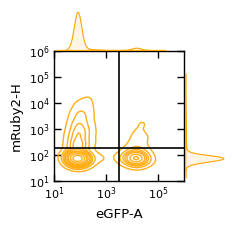

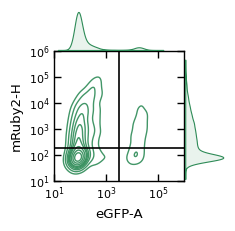

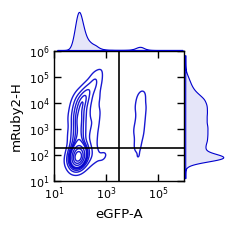

In [88]:
# General plotting params
y = "mRuby2-H"
x = "mGL-H"
hue = "Plasmid"
hue_order = Plasmid_conds_2

# Conditions
palette = {
    '0.1x': 'orange', 
    '0.5x': 'seagreen', 
    '1x': 'mediumblue'
}

for amount in Plasmid_conds_2:

        # Conditions
    data_now = data[
        (data['reporter'] == 'pKG05003') &
        (data['Plasmid'] == amount)
    ]

    small_data = pd.concat([data_now])

    # ----------------------------------------------------
    # Define bottom-left quadrant:
    # below BOTH gates
    # ----------------------------------------------------
    bottom_left = small_data[
        (small_data[x] < eGFP_gate) &
        (small_data[y] < mRuby2_gate_quantile)
    ]

    # Everything else
    not_bottom_left = small_data[
        ~(
            (small_data[x] < eGFP_gate) &
            (small_data[y] < mRuby2_gate_quantile)
        )
    ]

    # ----------------------------------------------------
    # Sample:
    # 1000 from bottom-left
    # 10000 from everything else
    # ----------------------------------------------------
    sampled_bottom_left = bottom_left.sample(
        min(len(bottom_left), 5000),
        random_state=1
    )

    sampled_not_bottom_left = not_bottom_left.sample(
        min(len(not_bottom_left), 5000),
        random_state=1
    )

    # Combine sampled data
    small_data_sampled = pd.concat([
        sampled_bottom_left,
        sampled_not_bottom_left
    ])

    # definitions for the axes
    left, width = 0.1, 0.65
    bottom, height = 0.1, 0.65
    spacing = 0.005

    rect_scatter = [left, bottom, width, height]
    rect_histx = [left, bottom + height + spacing, width, 0.2]
    rect_histy = [left + width + spacing, bottom, 0.2, height]

    # Set up figure
    fig = plt.figure(figsize=(2, 2))

    ax_scatter = plt.axes(rect_scatter)
    ax_scatter.tick_params(direction="in", top=True, right=True, labelsize=8)

    ax_histx = plt.axes(rect_histx)
    ax_histx.set_axis_off()

    ax_histy = plt.axes(rect_histy)
    ax_histy.set_axis_off()

    # Set limits
    mRuby2_lim = (10, 1e6)
    mCherry_lim = (10, 1e6)

    ylim = mRuby2_lim
    xlim = mCherry_lim

    ax_scatter.set_xlim(xlim)
    ax_scatter.set_ylim(ylim)

    ax_histx.set_xlim(xlim)
    ax_histy.set_ylim(ylim)

    # ----------------------------------------------------
    # Contour plot
    # ----------------------------------------------------
    sns.kdeplot(
        ax=ax_scatter,
        data=small_data_sampled,
        x=x,
        y=y,
        hue=hue,
        hue_order=hue_order,
        palette=palette,
        fill=False,
        levels=10,
        thresh=0.05,
        alpha=0.9,
        linewidths=1,
        legend=False,
        log_scale=True
    )

    ax_scatter.set_xscale('log')
    ax_scatter.set_yscale('log')



    # Remove minor ticks on the y-axis
    ax_scatter.yaxis.set_minor_locator(NullLocator())
    ax_scatter.tick_params(axis='y', which='minor', left=False, right=False)

    # Marginal KDEs
    sns.kdeplot(
        ax=ax_histx,
        data=small_data,
        x=x,
        hue=hue,
        hue_order=hue_order,
        alpha=0.1,
        palette=palette,
        log_scale=True,
        fill=True,
        common_norm=False,
        legend=False,
    )

    sns.kdeplot(
        ax=ax_histy,
        data=small_data,
        y=y,
        hue=hue,
        hue_order=hue_order,
        alpha=0.1,
        palette=palette,
        log_scale=True,
        fill=True,
        common_norm=False,
        legend=False,
    )

    # Thresholds
    ax_scatter.axhline(mRuby2_gate_quantile, 0, 1, color='black')
    ax_scatter.axvline(eGFP_gate, 0, 1, color='black')
    ax_scatter.set_xlabel('eGFP-A')

    fig.tight_layout()

    plottitle = str(amount) + 'pKG05003_height.svg'

    plt.savefig(
        rd.outfile(output_path / plottitle),
        bbox_inches='tight'
    )

**desNB contours**

In [ ]:
# General plotting params
y = "mRuby2-H"
x = "mGL-H"
hue = "Plasmid"
hue_order = Plasmid_conds_2

# Conditions
palette = {
    '0.1x': 'orange', 
    '0.5x': 'seagreen', 
    '1x': 'mediumblue'
}

for amount in Plasmid_conds_2:

        # Conditions
    data_now = data[
        (data['reporter'] == 'pKG05002') &
        (data['Plasmid'] == amount)
    ]

    small_data = pd.concat([data_now])

    # ----------------------------------------------------
    # Define bottom-left quadrant:
    # below BOTH gates
    # ----------------------------------------------------
    bottom_left = small_data[
        (small_data[x] < eGFP_gate) &
        (small_data[y] < mRuby2_gate_quantile)
    ]

    # Everything else
    not_bottom_left = small_data[
        ~(
            (small_data[x] < eGFP_gate) &
            (small_data[y] < mRuby2_gate_quantile)
        )
    ]

    # ----------------------------------------------------
    # Sample:
    # 1000 from bottom-left
    # 10000 from everything else
    # ----------------------------------------------------
    sampled_bottom_left = bottom_left.sample(
        min(len(bottom_left), 5000),
        random_state=1
    )

    sampled_not_bottom_left = not_bottom_left.sample(
        min(len(not_bottom_left), 5000),
        random_state=1
    )

    # Combine sampled data
    small_data_sampled = pd.concat([
        sampled_bottom_left,
        sampled_not_bottom_left
    ])

    # definitions for the axes
    left, width = 0.1, 0.65
    bottom, height = 0.1, 0.65
    spacing = 0.005

    rect_scatter = [left, bottom, width, height]
    rect_histx = [left, bottom + height + spacing, width, 0.2]
    rect_histy = [left + width + spacing, bottom, 0.2, height]

    # Set up figure
    fig = plt.figure(figsize=(2, 2))

    ax_scatter = plt.axes(rect_scatter)
    ax_scatter.tick_params(direction="in", top=True, right=True, labelsize=8)

    ax_histx = plt.axes(rect_histx)
    ax_histx.set_axis_off()

    ax_histy = plt.axes(rect_histy)
    ax_histy.set_axis_off()

    # Set limits
    mRuby2_lim = (10, 1e6)
    mCherry_lim = (10, 1e6)

    ylim = mRuby2_lim
    xlim = mCherry_lim

    ax_scatter.set_xlim(xlim)
    ax_scatter.set_ylim(ylim)

    ax_histx.set_xlim(xlim)
    ax_histy.set_ylim(ylim)

    # ----------------------------------------------------
    # Contour plot
    # ----------------------------------------------------
    sns.kdeplot(
        ax=ax_scatter,
        data=small_data_sampled,
        x=x,
        y=y,
        hue=hue,
        hue_order=hue_order,
        palette=palette,
        fill=False,
        levels=10,
        thresh=0.05,
        alpha=0.9,
        linewidths=1,
        legend=False,
        log_scale=True
    )

    ax_scatter.set_xscale('log')
    ax_scatter.set_yscale('log')



    # Remove minor ticks on the y-axis
    ax_scatter.yaxis.set_minor_locator(NullLocator())
    ax_scatter.tick_params(axis='y', which='minor', left=False, right=False)

    # Marginal KDEs
    sns.kdeplot(
        ax=ax_histx,
        data=small_data,
        x=x,
        hue=hue,
        hue_order=hue_order,
        alpha=0.1,
        palette=palette,
        log_scale=True,
        fill=True,
        common_norm=False,
        legend=False,
    )

    sns.kdeplot(
        ax=ax_histy,
        data=small_data,
        y=y,
        hue=hue,
        hue_order=hue_order,
        alpha=0.1,
        palette=palette,
        log_scale=True,
        fill=True,
        common_norm=False,
        legend=False,
    )

    # Thresholds
    ax_scatter.axhline(mRuby2_gate_quantile, 0, 1, color='black')
    ax_scatter.axvline(eGFP_gate, 0, 1, color='black')
    ax_scatter.set_xlabel('eGFP-A')

    fig.tight_layout()

    plottitle = str(amount) + 'pKG05002_height.svg'

    plt.savefig(
        rd.outfile(output_path / plottitle),
        bbox_inches='tight'
    )